<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
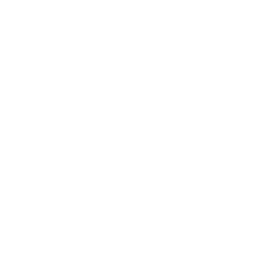
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ανάλυση Ομοιότητας Προγράμματος Σπουδών</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ανώτατη Εκπαίδευση / Σχεδιασμός Ακαδημαϊκού Προγράμματος &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για τη Διοίκηση

Αυτό το notebook μετρά την επικάλυψη των προγραμμάτων σπουδών σε έναν
πανεπιστημιακό κατάλογο μαθημάτων χρησιμοποιώντας το **PROC DISTANCE** με
**METHOD=DJACCARD** — τον συντελεστή *ανομοιότητας* Jaccard, τη φυσική
απόσταση για δυαδικά δεδομένα παρουσίας/απουσίας. Κάθε μάθημα φέρει 40
δυαδικές σημαίες που δηλώνουν ποια μαθησιακά αποτελέσματα πιστοποίησης
καλύπτει, οπότε η απόσταση Jaccard μεταξύ δύο μαθημάτων είναι το ποσοστό
των καλυπτόμενων αποτελεσμάτων που **δεν** έχουν κοινά (0 = ταυτόσημα
σύνολα αποτελεσμάτων, 1 = κανένα κοινό αποτέλεσμα).

Η ανάλυση εκτελείται σε δύο μέρη. Πρώτον, σε έναν κατάλογο 100 μαθημάτων
περιγράφει το εύρος κάλυψης αποτελεσμάτων ανά τμήμα (PROC MEANS, PROC FREQ,
ένα διάγραμμα πλαισίου κάλυψης) και επισημαίνει τα μαθησιακά αποτελέσματα
που **κανένα** μάθημα ενός τμήματος δεν καλύπτει (κενά κάλυψης). Δεύτερον,
εστιάζει σε ένα εστιασμένο σύνολο 10 μαθημάτων από τα δύο τμήματα με τη
μεγαλύτερη ποσοτική επικάλυψη — Στατιστική και Επιστήμη Δεδομένων —
υπολογίζει τον πλήρη πίνακα ανά ζεύγη αποστάσεων Jaccard και κατατάσσει
τα πλησιέστερα ζεύγη μαθημάτων ως υποψήφια για εξέταση ενοποίησης. Στόχος
είναι να δοθούν σε μια επιτροπή προγράμματος σπουδών δύο συγκεκριμένα
τεκμήρια: μια κατατεταγμένη λίστα των πιο όμοιων μαθημάτων και έναν χάρτη
κενών ανά τμήμα και αποτέλεσμα.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Δυαδική κάλυψη μαθησιακών αποτελεσμάτων ανά μάθημα (40 σημαίες αποτελεσμάτων) | 100 |
| WORK.PANEL10 | Σύνολο ενοποίησης Στατιστικής + Επιστήμης Δεδομένων | 10 |

Ο κατάλογος είναι συνθετικός. Οι σημαίες αποτελεσμάτων παράγονται με
πιθανότητες ειδικές ανά τμήμα, ώστε οι κλάδοι να δίνουν έμφαση σε
διαφορετικές ομάδες αποτελεσμάτων (η επιστήμη υπολογιστών και τα
μαθηματικά σταθμίζουν τα πρώιμα αποτελέσματα, οι εργαστηριακές επιστήμες
σταθμίζουν τη μεσαία ζώνη), δίνοντας στην ανάλυση αποστάσεων ρεαλιστική
δομή. Αυτό το περιβάλλον εκτελείται χωρίς άδεια χρήσης, οπότε ο κατάλογος
εργασίας περιορίζεται σε 100 μαθήματα.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic course learning-outcome matrix
   500 courses x 40 accreditation learning outcomes
   (unlicensed mode keeps the first 100)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.course_outcomes;
    CALL streaminit(42);
    ARRAY outcomes[40] lo_1 - lo_40;
    ARRAY dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    ΕΠΑΝΑΛΗΨΗ course_id = 1 ΕΩΣ 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Course level affects outcome breadth */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Department-specific outcome clusters */
        ΕΠΑΝΑΛΗΨΗ lo = 1 ΕΩΣ 40;
            base_prob = 0.15;
            /* Dept 1-2 (CS, Math): emphasize outcomes 1-15 */
            ΕΑΝ dept_idx <= 2 AND lo <= 15 ΤΟΤΕ
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Stats, Eng): emphasize outcomes 10-25 */
            ΑΛΛΙΩΣ ΕΑΝ dept_idx IN (3, 4) AND 10 <= lo <= 25 ΤΟΤΕ
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Bio, Chem, Phys): emphasize 20-35 */
            ΑΛΛΙΩΣ ΕΑΝ dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 ΤΟΤΕ
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Data Sci): broad coverage */
            ΑΛΛΙΩΣ ΕΑΝ dept_idx = 8 ΤΟΤΕ
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        ΤΕΛΟΣ;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΕΤΙΚΕΤΑ department='Τμήμα';
    ΑΦΑΙΡΕΣΗ dept_idx course_level base_prob lo;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.81 seconds
  cpu   1.81 seconds


In [2]:
/* --------------------------------------------------------
   Generate course catalog metadata
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.course_catalog;
    CALL streaminit(43);
    ARRAY dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    ARRAY format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    ΕΠΑΝΑΛΗΨΗ course_id = 1 ΕΩΣ 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΕΤΙΚΕΤΑ department='Τμήμα' level_code='Επίπεδο';
    ΑΦΑΙΡΕΣΗ dept_idx format_idx;
    ΜΟΡΦΗ last_offered date9.;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                     Μέση Κάλυψη Μαθησιακών Αποτελεσμάτων ανά Τμήμα                                     

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                            N
                                           Τμήμα          Obs           Mean
                                           ---------------------------------
                                           BIOLOGY         10      0.2000000
                                           CHEMISTRY       19      0.2105263
                                           COMP_SCI        13      0.3846154
                                           DATA_SCI        14      0.1428571
                                           ENGINEERING     17      0.0000000
                                           MATH             9      0.6666667
                                           PHYSICS      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


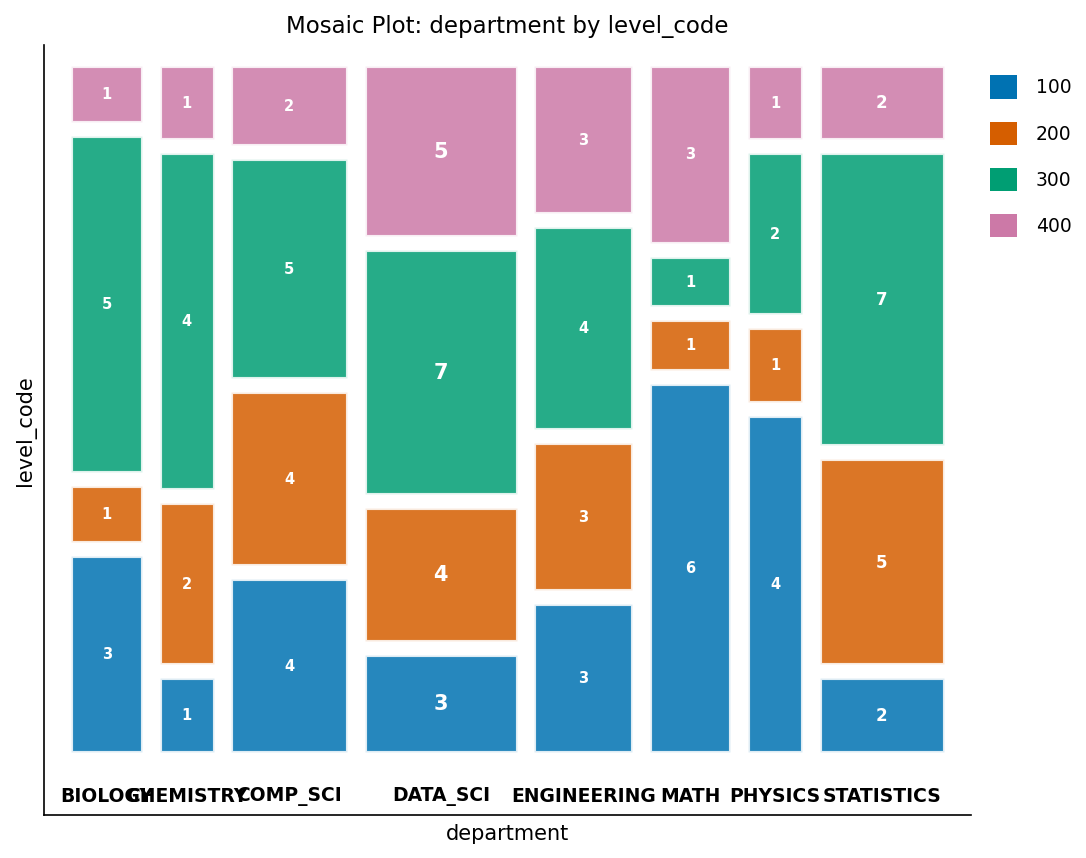

In [3]:
/* --------------------------------------------------------
   Baseline learning outcome coverage by department
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.course_outcomes mean;
    ΚΛΑΣΗ department;
    ΜΕΤΑΒΛΗΤΗ lo_1 - lo_40;
    TITLE 'Μέση Κάλυψη Μαθησιακών Αποτελεσμάτων ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    TITLE 'Κατανομή Μαθημάτων ανά Τμήμα και Επίπεδο';
ΕΚΤΕΛΕΣΗ;

---

                                        Κατανομή Μαθημάτων ανά Τμήμα και Επίπεδο                                        




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


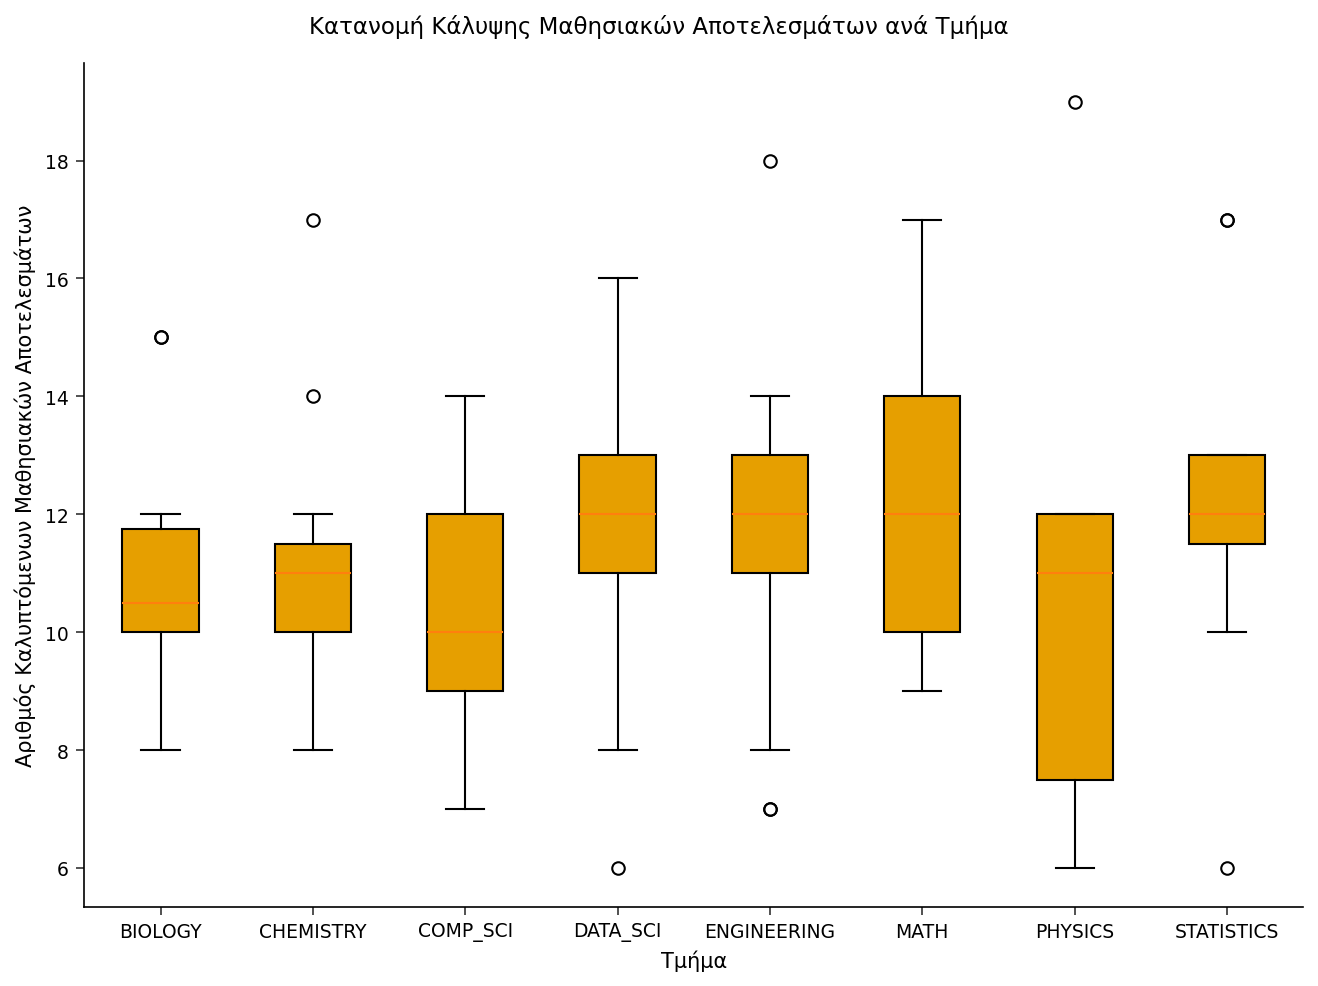

In [4]:
/* --------------------------------------------------------
   Outcome coverage density by department
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.outcome_counts;
    ΟΡΙΣΜΟΣ work.course_outcomes;
    ARRAY outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS ΕΤΙΚΕΤΑ='Αριθμός Καλυπτόμενων Μαθησιακών Αποτελεσμάτων';
    XAXIS ΕΤΙΚΕΤΑ='Τμήμα';
    TITLE 'Κατανομή Κάλυψης Μαθησιακών Αποτελεσμάτων ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

---

In [5]:
/* --------------------------------------------------------
   Consolidation panel: the first 10 Statistics / Data
   Science courses (the two most quantitatively overlapping
   departments). Re-label them P01-P10 with a sequential
   counter so the square OUT= distance matrix has clean,
   addressable columns, then compute the full pairwise
   Jaccard DISTANCE matrix with METHOD=DJACCARD
   (0 = identical outcome sets, 1 = no shared outcome).
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.panel10;
    ΟΡΙΣΜΟΣ work.course_outcomes(ΟΠΟΥ=(department IN ('STATISTICS' 'DATA_SCI')));
    RETAIN seq 0;
    seq + 1;
    ΕΑΝ seq > 10 ΤΟΤΕ STOP;
    panel_id = cat('P', PUT(seq, z2.));
    ΑΦΑΙΡΕΣΗ seq;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.panel10 noobs ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ panel_id course_label department level_code;
    ΕΤΙΚΕΤΑ panel_id = 'Κωδικός Πάνελ' course_label = 'Μάθημα'
          department = 'Τμήμα' level_code = 'Επίπεδο';
    TITLE 'Πάνελ Ενοποίησης: Μαθήματα Στατιστικής και Επιστήμης Δεδομένων';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ distance ΔΕΔΟΜΕΝΑ=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    ΜΕΤΑΒΛΗΤΗ nominal(lo_1 - lo_40);
    id panel_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.panel_dist noobs;
    TITLE 'Πίνακας Αποστάσεων Jaccard ανά Ζεύγη (10 Μαθήματα)';
ΕΚΤΕΛΕΣΗ;

                             Πάνελ Ενοποίησης: Μαθήματα Στατιστικής και Επιστήμης Δεδομένων                             

            Κωδικός Πάνελ        Μάθημα       Τμήμα         Επίπεδο
P01                        CRS0003       DATA_SCI               300
P02                        CRS0006       STATISTICS             300
P03                        CRS0014       DATA_SCI               300
P04                        CRS0015       STATISTICS             300
P05                        CRS0017       STATISTICS             200
P06                        CRS0019       DATA_SCI               100
P07                        CRS0022       STATISTICS             400
P08                        CRS0033       DATA_SCI               200
P09                        CRS0038       STATISTICS             100
P10                        CRS0040       STATISTICS             100

                             Πάνελ Ενοποίησης: Μαθήματα Στατιστικής και Επιστήμης Δεδομένων                             

       


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reshape the square distance matrix into a ranked list of
   course pairs. The OUT= distance columns are addressed by
   an explicit name list (P01 P02 ... P10); only the strict
   upper triangle (col > row) is kept so each unordered pair
   appears once and the zero diagonal is skipped. The five
   closest pairs are the consolidation-review candidates.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.similar_courses;
    ΟΡΙΣΜΟΣ work.panel_dist;
    ARRAY d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LENGTH course_a course_b $8;
    course_a = _name_;
    row + 1;
    ΕΠΑΝΑΛΗΨΗ col = 1 ΕΩΣ 10;
        ΕΑΝ col > row ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ course_a course_b jaccard_dist;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    ΜΕΤΑΒΛΗΤΗ jaccard_dist;
    TITLE 'Κατανομή Αποστάσεων Jaccard ανά Ζεύγη (45 Ζεύγη Μαθημάτων)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.similar_courses; ΚΑΤΑ jaccard_dist; ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.top_pairs;
    ΟΡΙΣΜΟΣ work.similar_courses;
    pair_rank = _n_;
    ΕΑΝ pair_rank <= 5;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.top_pairs noobs ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ pair_rank course_a course_b jaccard_dist;
    ΕΤΙΚΕΤΑ pair_rank = 'Κατάταξη' course_a = 'Μάθημα Α'
          course_b = 'Μάθημα Β' jaccard_dist = 'Απόσταση Jaccard';
    TITLE 'Τα Πέντε Πλησιέστερα Ζεύγη Μαθημάτων (Υποψήφια προς Ενοποίηση)';
ΕΚΤΕΛΕΣΗ;

                               Κατανομή Αποστάσεων Jaccard ανά Ζεύγη (45 Ζεύγη Μαθημάτων)                               

                                                  The MEANS Procedure

 Variable            N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------
 jaccard_dist       45       0.588            0.762       0.826       0.818       0.962
 --------------------------------------------------------------------------------------

                             Τα Πέντε Πλησιέστερα Ζεύγη Μαθημάτων (Υποψήφια προς Ενοποίηση)                             

        Κατάταξη         Μάθημα Α         Μάθημα Β          Απόσταση Jaccard
               1  P02              P10                                 0.588
               2  P03              P04                                   0.6
               3  P03              P05                                 0.667
               4  P02   


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                    Μη Καλυπτόμενα Μαθησιακά Αποτελέσματα ανά Τμήμα                                     

                                                   The FREQ Procedure

department     Frequency    Percent
------------------------------------
BIOLOGY                8     26.67
CHEMISTRY              2      6.67
COMP_SCI               3     10.00
ENGINEERING            2      6.67
MATH                   4     13.33
PHYSICS                8     26.67
STATISTICS             3     10.00
                                  Δείγμα Κενών Κάλυψης Αποτελεσμάτων (πρώτα 12 από 30)                                  

     Τμήμα                         Μη Καλυπτόμενο Αποτέλεσμα
BIOLOGY     LO02
BIOLOGY     LO10
BIOLOGY     LO15
BIOLOGY     LO16
BIOLOGY     LO17
BIOLOGY     LO18
BIOLOGY     LO36
BIOLOGY     LO37
CHEMISTRY   LO02
CHEMISTRY   LO12
COMP_SCI    LO29
COMP_SCI    LO35

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


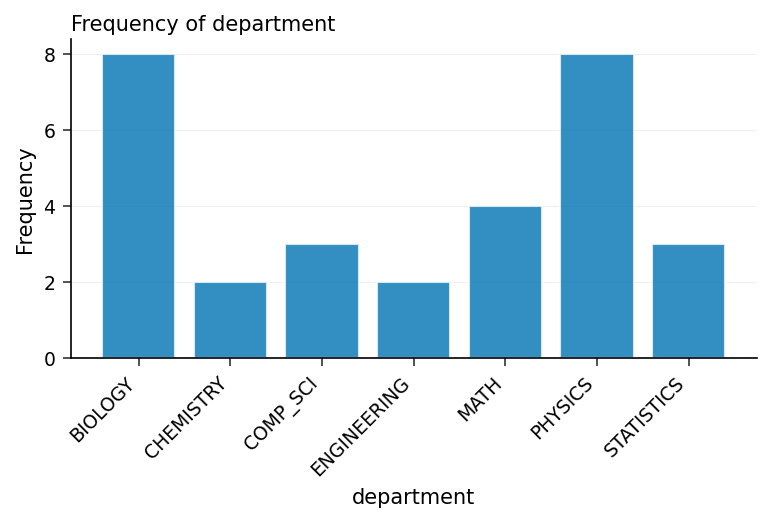

In [7]:
/* --------------------------------------------------------
   Outcome gaps: learning outcomes that NO course in a
   department covers. PROC MEANS sums each binary outcome
   flag within department; a sum of zero means the
   outcome is absent from that department's catalog.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.course_outcomes sum NOPRINT;
    ΚΛΑΣΗ department;
    ΜΕΤΑΒΛΗΤΗ lo_1 - lo_40;
    ΕΞΟΔΟΣ out=work.dept_coverage(ΟΠΟΥ=(_type_=1))
        sum=lo_1 - lo_40;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.outcome_gaps;
    ΟΡΙΣΜΟΣ work.dept_coverage;
    ARRAY outcomes[40] lo_1 - lo_40;
    ΕΠΑΝΑΛΗΨΗ lo = 1 ΕΩΣ 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        ΕΑΝ courses_covering = 0 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            gap_flag = 1;
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ department outcome_id courses_covering gap_flag;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.outcome_gaps;
    TABLES department / nocum;
    TITLE 'Μη Καλυπτόμενα Μαθησιακά Αποτελέσματα ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.outcome_gaps(obs=12) noobs ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ department outcome_id;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' outcome_id = 'Μη Καλυπτόμενο Αποτέλεσμα';
    TITLE 'Δείγμα Κενών Κάλυψης Αποτελεσμάτων (πρώτα 12 από 30)';
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

**Σύνολο ενοποίησης.** Στα 45 μη διατεταγμένα ζεύγη του συνόλου 10
μαθημάτων Στατιστικής / Επιστήμης Δεδομένων, η απόσταση Jaccard κυμαίνεται
από 0.588 έως 0.962 με διάμεσο 0.826 (μέσος όρος 0.818). Το πλησιέστερο
ζεύγος είναι τα P02 και P10 σε απόσταση 0.588, ακολουθούμενο από τα
P03–P04 στο 0.600 και τα P03–P05 στο 0.667. Ακόμη και τα πιο όμοια
μαθήματα διαφέρουν σε περίπου 59% των καλυπτόμενων αποτελεσμάτων τους,
οπότε αυτός ο κατάλογος **δεν περιέχει σχεδόν διπλότυπα μαθήματα** — δεν
υπάρχει ζεύγος που μια επιτροπή θα μπορούσε να συγχωνεύσει άμεσα. Αντ'
αυτού, η κατατεταγμένη λίστα υποδεικνύει τα λίγα ζεύγη που αξίζουν μια
χειροκίνητη σύγκριση προγραμμάτων ύλης πριν από τον επόμενο κύκλο
καταλόγου· τα ζεύγη με τη μεγαλύτερη απόσταση (κοντά στο 0.962)
επιβεβαιώνουν ότι τα μαθήματα Στατιστικής και Επιστήμης Δεδομένων, παρότι
μοιράζονται μια γειτονιά τμημάτων, καλύπτουν πραγματικά διακριτά σύνολα
αποτελεσμάτων.

**Κενά αποτελεσμάτων.** Τριάντα κενά ανά τμήμα και αποτέλεσμα εμφανίζονται
σε όλον τον κατάλογο. Οι κλάδοι με πολλά εργαστήρια φέρουν τα περισσότερα:
η **Βιολογία** και η **Φυσική** αφήνουν η καθεμία 8 από τα 40 αποτελέσματα
πιστοποίησης ακάλυπτα, ακολουθούμενες από τα **Μαθηματικά** (4). Τα
ποσοτικά τμήματα είναι τα καλύτερα καλυμμένα — η **Χημεία** και η
**Μηχανική** χάνουν μόνο 2 αποτελέσματα η καθεμία. Αυτά τα κενά είναι οι
φυσικοί στόχοι για ανάπτυξη νέων μαθημάτων ή διατμηματική καταχώριση: ένα
αποτέλεσμα που απουσιάζει από ένα ολόκληρο τμήμα αποτελεί κίνδυνο κάλυψης
κατά την ανανέωση πιστοποίησης, ενώ η λίστα ενοποίησης αντιμετωπίζει το
αντίθετο πρόβλημα της πλεονάζουσας προσπάθειας. Μαζί, τα δύο τεκμήρια
επιτρέπουν στην επιτροπή να σφίξει τον κατάλογο και από τα δύο άκρα —
περικόπτοντας την επικάλυψη και γεμίζοντας τις ερήμους — χρησιμοποιώντας
ένα μέτρο απόστασης βασισμένο σε σύνολα.

---

In [8]:
/* --------------------------------------------------------
   Export the ranked consolidation candidates and the
   department outcome-gap map for the curriculum committee.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>